# setup

In [1]:
import pandas as pd
from collections import Counter
import json
from pathlib import Path
import random
from sklearn.model_selection import StratifiedKFold, KFold
import seaborn as sns
sns.set_theme(style="darkgrid")
import numpy as np
import requests
import pickle
from tqdm import tqdm
import networkx as nx
import os
import subprocess
from sklearn.feature_extraction.text import CountVectorizer

## helpers

In [2]:
def load_samples(dataset):
    with open(f"resource/dataset/{dataset}/samples.pkl", "rb") as samples_file:
        return pickle.load(samples_file)

def get_scores(scores_path):

    scores = []
    with open(scores_path) as scores_file:
        for score in scores_file:
            scores.append(int(score))
    return pd.DataFrame(scores, columns=["cls"])

def get_texts(texts_path):
    texts = []
    with open(texts_path, "rb") as texts_file:
        for text in texts_file:
            text = text.decode('utf-8')
            #text.replace("\n", " ")
            text = text.replace("\n", " ").replace("\r", " ").strip()

            texts.append(text)
    return pd.DataFrame(texts, columns=["text"])

def get_splits(splits_path):
    with open(splits_path, "rb") as splits_file:
        return pickle.load(splits_file)

def get_samples (texts_path, scores_path):
    texts_df = get_texts(texts_path)
    scores_df = get_scores(scores_path)
    samples_df = texts_df.join(scores_df)
    samples_df["idx"] = samples_df.index
    samples_df["cls"] = pd.factorize(samples_df["cls"], sort=True)[0]
    return samples_df[["idx", "text", "cls"]]

In [3]:
def download_dataset(dataset, dataset_dir, base_url="http://150.164.2.44/datasets/"):
    # Create the target directory if it doesn't exist
    os.makedirs(dataset_dir, exist_ok=True)

    # Wget command to recursively download files into the target directory
    cmd = [
        "wget", "-r", "-np", "-nH", "--cut-dirs=2",
        "-R", "index.html*", "-P", dataset_dir, f"{base_url}{dataset}/"
    ]

    try:
        subprocess.run(cmd, check=True)
        print(f"Dataset downloaded successfully to '{dataset_dir}'")
    except subprocess.CalledProcessError as e:
        print(f"Error downloading dataset: {e}")

### folds

In [4]:
def get_splits(splits_path):
    with open(splits_path, "rb") as splits_file:
        return pickle.load(splits_file)

In [5]:
def train_val_split(ids, split_indice=.9):
    random.shuffle(ids)
    return np.split(
        ids,
            [
            int(
                split_indice*len(ids)
                )
            ]
         )

def k_fold_split(ids, n_splits=5, random_state=72, shuffle=True):
    folds=[]

    kf=KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    for fold_idx, splits in enumerate(kf.split(ids)):

        train_ids, val_ids = train_val_split(splits[0].tolist())
        test_ids=splits[1].tolist()

        folds.append({
            "fold_idx": fold_idx,
            "splits": {
                "train": train_ids.tolist(),
                "val": val_ids.tolist(),
                "test": test_ids
                }
            })

    return folds

def sk_fold_split(ids, cls, n_splits=5, random_state=72, shuffle=True):
    folds=[]
    kf=StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    for fold_idx, splits in enumerate(kf.split(ids, cls)):

        train_ids, val_ids = train_val_split(splits[0].tolist())
        test_ids=splits[1].tolist()

        folds.append({
            "fold_idx": fold_idx,
            "splits": {
                "train": [ids[idx] for idx in train_ids], #ids[train_ids],
                "val": [ids[idx] for idx in val_ids], #ids[val_ids],
                "test": [ids[idx] for idx in test_ids] #ids[test_ids]
                }
            })

    return folds

def show_folds(folds, samples_to_show=10):
    for fold in folds:
        splits = fold['splits']
        print(f"fold: {fold['fold_idx']} ")
        print(f"train({len(splits['train'])}): {splits['train'][:samples_to_show]} ")
        print(f"val({len(splits['val'])}): {splits['val'][:samples_to_show]} ")
        print(f"test({len(splits['test'])}): {splits['test'][:samples_to_show]} \n")

In [6]:
ids = [0, 1, 2, 3]
k_fold_split(ids,n_splits=2)

[{'fold_idx': 0, 'splits': {'train': [2], 'val': [0], 'test': [1, 3]}},
 {'fold_idx': 1, 'splits': {'train': [1], 'val': [3], 'test': [0, 2]}}]

In [7]:
def load_K_fold_split(splits_df):
    folds=[]
    for _, splits in splits_df.iterrows():
        folds.append({
            "fold_idx": splits["fold_id"],
            "splits": {
                "train": splits["train_idxs"],
                "val": splits["val_idxs"],
                "test": splits["test_idxs"]
                }
            })

    return folds

### checkpoint

In [8]:
def checkpoint_samples(samples_df, dataset_dir):
    samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
    with open(dataset_dir+"samples.pkl", "wb") as samples_file:
        pickle.dump(samples_df.to_dict(orient="records"), samples_file)

In [9]:
def checkpoint_folds(folds, dataset_dir):
    for fold in folds:
        fold_dir = f"{dataset_dir}fold_{fold['fold_idx']}/"
        Path(fold_dir).mkdir(parents=True, exist_ok=True)
        for split, split_ids in fold['splits'].items():
            with open(f"{fold_dir}{split}.pkl", "wb") as split_file:
                pickle.dump(split_ids,split_file)


In [10]:
def checkpoint_relevance_map(relevance_map, dataset_dir):
    with open(dataset_dir+"relevance_map.pkl", "wb") as relevance_map_file:
        pickle.dump(relevance_map, relevance_map_file)

In [11]:
def checkpoint_label_cls(label_cls, dataset_dir):
    with open(dataset_dir+"label_cls.pkl", "wb") as label_cls_file:
        pickle.dump(label_cls, label_cls_file)

In [12]:
def checkpoint_labels_propensities(labels_propensities, dataset_dir):
    with open(dataset_dir+"labels_propensities.pkl", "wb") as labels_propensities_file:
        pickle.dump(labels_propensities, labels_propensities_file)

In [13]:
def checkpoint_text_cls(text_cls, dataset_dir):
    with open(dataset_dir+"text_cls.pkl", "wb") as text_cls_file:
        pickle.dump(text_cls, text_cls_file)

In [14]:
def checkpoint_labels_map(labels_map, dataset_dir):
    with open(dataset_dir+"labels_map.pkl", "wb") as labels_map_file:
        pickle.dump(labels_map, labels_map_file)

### dist

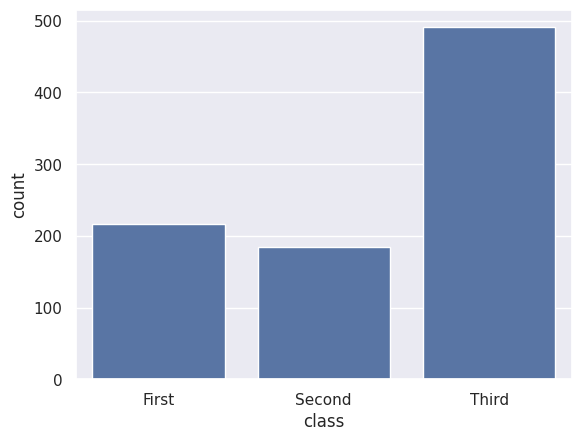

In [15]:
titanic = sns.load_dataset("titanic")
ax = sns.countplot(x="class", data=titanic)

In [16]:
def plot_label_distribution(samples_df, column):
    samples = []
    for idx, row in samples_df.iterrows():
        for label_idx in row[column]:
            samples.append(label_idx)
    return sns.countplot(samples)

### stats

In [17]:
def get_max_num_tokens(labels):
    max_num_tokens = 0
    for label in labels:
        num_tokens = len(label.split())
        if num_tokens > max_num_tokens:
            max_num_tokens = num_tokens
    return max_num_tokens

def len_stats (df):
    df = df.copy()
    df['text_len'] = df["text"].apply(lambda x: len(x.split()))
    text_len_summary = df['text_len'].quantile([.01, .5, .7, .8, .9, .95])
    display(pd.DataFrame(text_len_summary))

    df['label_len'] = df["labels"].apply(lambda labels: len(' '.join(labels).split()) )
    label_len_summary = df['label_len'].quantile([.5, .7, .8, .9, .95])
    display(pd.DataFrame(label_len_summary))

In [18]:
def inspect_stat(dataset):
    data_dir = f"resource/dataset/{dataset}/"
    with open(f"{data_dir}samples_with_keywords.pkl", "rb") as dataset_file:
        samples = pickle.load(dataset_file)
    samples_df = pd.DataFrame(samples)
    with open(f"{data_dir}label_cls.pkl", "rb") as f2:
        labels_cls = pickle.load(f2)

    t, h = [], [ ]
    for _, r in samples_df.iterrows():
        t_count, h_count = 0, 0
        for label_idx in r["labels_ids"]:
            if "tail" in labels_cls[label_idx]:
                t_count+=1
            if "head" in labels_cls[label_idx]:
                h_count+=1
        t.append(t_count)
        h.append(h_count)

## relevance

In [19]:
def get_relevance_map(df):
    relevance_map = {}
    qs1_ids = df["qs1_idx"].unique().tolist()
    qs1_ids.sort()
    qs2_ids = df["qs2_idx"].unique().tolist()
    qs2_ids.sort()

    for idx, row in df.iterrows():
        if row["cls"]==1:
            relevance_map.setdefault(row["qs1_idx"], [])
            relevance_map[row["qs1_idx"]].append(row["qs2_idx"])
    return relevance_map

## text and labels cls

In [20]:
def get_text_cls(label_ids, label_cls):
    cls = []
    for label_idx in label_ids:
        cls.extend(label_cls[label_idx])
    return list(set(cls))

# Main


## ACM

In [21]:
dataset = "ACM"
dataset_raw_name = "acm"
labels_names = ["general literature", "hardware",
                "computer systems organization", "software", "data",
                "theory of computation", "mathematics of computing",
                "information systems", "computing methodologies",
                "computer applications", "computing milieux"]
len(labels_names)

11

In [22]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

Dataset downloaded successfully to 'resource/dataset/raw_dataset/ACM/'


### samples

In [23]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,4159,anisotropic reflection models james t. kajiya,[6],[mathematics of computing]
1,1,6980,"corrigenda: ""an extended set of fortran basic ...",[6],[mathematics of computing]
2,2,3070,algorithm 677 _c_1 surface interpolation laura...,[6],[mathematics of computing]
3,3,1822,"a remark on algorithm 644: ""a portable package...",[6],[mathematics of computing]
4,4,9985,"fitting ""standard"" distributions to data is ne...",[6],[mathematics of computing]
...,...,...,...,...,...
24892,24892,16667,president's letter paul abrahamsss,[0],[general literature]
24893,24893,2612,acm forum robert l. ashenhurst,[0],[general literature]
24894,24894,22530,transcript of the popular interactive televisi...,[0],[general literature]
24895,24895,2612,acm forum robert l. ashenhurst,[0],[general literature]


### labels cls

In [24]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 3
Num tail labels: 8
Total num labels: 11


### text cls

In [25]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

24198

### len stats

In [26]:
len_stats(samples_df)

,text_len
0.01,3.96
0.50,16.00
0.70,80.00
0.80,122.00
0.90,171.00
0.95,214.00


,label_len
0.50,2.0
0.70,2.0
0.80,2.0
0.90,3.0
0.95,3.0


### folds

In [27]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,val_idxs,test_idxs
0,0,"[0, 1, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15, 16, ...","[2, 3, 6, 13, 32, 43, 47, 52, 80, 88, 89, 98, ...","[23, 30, 39, 44, 63, 67, 70, 72, 86, 96, 107, ..."
1,1,"[0, 1, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18...","[3, 4, 8, 15, 34, 44, 47, 53, 85, 92, 93, 101,...","[2, 5, 31, 33, 49, 54, 60, 65, 66, 76, 77, 78,..."
2,2,"[0, 1, 4, 5, 8, 9, 11, 12, 13, 14, 16, 17, 18,...","[2, 3, 6, 15, 34, 44, 47, 52, 78, 88, 89, 98, ...","[7, 10, 25, 29, 55, 59, 79, 81, 84, 97, 101, 1..."
3,3,"[0, 1, 4, 5, 8, 9, 10, 11, 13, 14, 16, 17, 19,...","[2, 3, 7, 15, 35, 46, 49, 55, 84, 92, 93, 101,...","[6, 12, 18, 24, 28, 41, 51, 56, 61, 69, 73, 83..."
4,4,"[0, 1, 5, 6, 8, 10, 12, 13, 14, 16, 18, 19, 20...","[2, 4, 7, 17, 35, 47, 50, 55, 80, 87, 88, 101,...","[3, 9, 11, 15, 22, 42, 43, 74, 89, 92, 93, 94,..."
5,5,"[1, 2, 5, 6, 8, 9, 10, 11, 12, 13, 15, 16, 18,...","[3, 4, 7, 14, 33, 44, 48, 54, 81, 89, 90, 98, ...","[0, 17, 19, 38, 46, 50, 57, 68, 75, 88, 116, 1..."
6,6,"[0, 1, 4, 5, 7, 9, 10, 11, 12, 13, 15, 17, 18,...","[2, 3, 6, 14, 33, 46, 50, 56, 80, 87, 88, 96, ...","[8, 16, 26, 36, 37, 45, 48, 53, 103, 111, 115,..."
7,7,"[0, 1, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15, 16, ...","[2, 3, 6, 13, 30, 40, 43, 48, 72, 79, 80, 88, ...","[112, 122, 123, 129, 143, 146, 147, 183, 186, ..."
8,8,"[0, 1, 5, 6, 8, 9, 10, 11, 12, 13, 16, 17, 18,...","[2, 3, 7, 15, 34, 46, 50, 56, 82, 90, 91, 101,...","[4, 14, 27, 32, 35, 40, 47, 52, 62, 64, 85, 95..."
9,9,"[0, 2, 5, 6, 8, 9, 10, 11, 12, 14, 16, 17, 18,...","[3, 4, 7, 15, 35, 45, 48, 53, 79, 88, 89, 98, ...","[1, 13, 20, 21, 34, 58, 71, 80, 87, 91, 99, 10..."


In [28]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(20161): [0, 1, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19] 
val(2241): [2, 3, 6, 13, 32, 43, 47, 52, 80, 88, 89, 98, 99, 116, 117, 125] 
test(2495): [23, 30, 39, 44, 63, 67, 70, 72, 86, 96, 107, 120, 136, 139, 158, 174] 

fold: 1 
train(20162): [0, 1, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21] 
val(2241): [3, 4, 8, 15, 34, 44, 47, 53, 85, 92, 93, 101, 102, 120, 121, 128] 
test(2494): [2, 5, 31, 33, 49, 54, 60, 65, 66, 76, 77, 78, 82, 109, 110, 137] 

fold: 2 
train(20163): [0, 1, 4, 5, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21] 
val(2241): [2, 3, 6, 15, 34, 44, 47, 52, 78, 88, 89, 98, 99, 116, 117, 125] 
test(2493): [7, 10, 25, 29, 55, 59, 79, 81, 84, 97, 101, 118, 133, 148, 155, 196] 

fold: 3 
train(20165): [0, 1, 4, 5, 8, 9, 10, 11, 13, 14, 16, 17, 19, 20, 21, 22] 
val(2241): [2, 3, 7, 15, 35, 46, 49, 55, 84, 92, 93, 101, 102, 119, 120, 127] 
test(2491): [6, 12, 18, 24, 28, 41, 51, 56, 61, 69, 73, 83, 90, 108, 131, 132] 

fold: 4 
train(20166): [0,

### relevance map

In [29]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

24198

### checkpoint

In [30]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing ACM dataset



## REUTERS

In [31]:
dataset = "REUTERS"
dataset_raw_name = "reut90"
labels_names = ["rape-oil", "groundnut-oil", "dmk", "cpi", "meal-feed", "wpi",
                "livestock", "palm-oil", "jobs", "palladium", "nzdlr",
                "sunseed", "alum", "sorghum", "potato", "carcass", "money-fx",
                "grain", "coffee", "hog", "palmkernel", "rand", "zinc", "heat",
                "interest", "orange", "oilseed", "rice", "lumber", "rubber",
                "cotton", "crude", "fuel", "cocoa", "coconut", "nkr",
                "platinum", "coconut-oil", "instal-debt", "acq", "ship", "earn",
                "lei", "sugar", "dlr", "sun-meal", "naphtha", "lead",
                "pet-chem", "oat", "jet", "l-cattle", "trade", "castor-oil",
                "tea", "money-supply", "dfl", "retail", "income", "gas",
                "copper", "nickel", "barley", "corn", "rapeseed", "copra-cake",
                "propane", "veg-oil", "soy-meal", "tin", "groundnut", "wheat",
                "iron-steel", "reserves", "lin-oil", "silver", "gnp", "yen",
                "housing", "soy-oil", "sun-oil", "strategic-metal", "cpu",
                "nat-gas", "ipi", "gold", "rye", "soybean", "cotton-oil",
                "bop"]
len(labels_names)

90

In [32]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

Dataset downloaded successfully to 'resource/dataset/raw_dataset/REUTERS/'


### samples

In [33]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,4330,growth of palm oil use set to slow output to r...,[0],[rape-oil]
1,1,4833,india bought 24 000 tonnes of rbd olein at ten...,[0],[rape-oil]
2,2,7808,rpt argentine grain oilseed export prices adju...,[0],[rape-oil]
3,3,167,algeria sets tender for rape sunflowerseed oil...,[0],[rape-oil]
4,4,4836,india buys 46 000 tonnes of vegetable oils lo...,[0],[rape-oil]
...,...,...,...,...,...
13322,13322,631,australia set to grow but unemployment may ris...,[89],[bop]
13323,13323,4124,german may current account surplus 7 5 billion...,[89],[bop]
13324,13324,732,baker sees 15 to 20 billion dlr drop in trade ...,[89],[bop]
13325,13325,8283,south korea moves to slow growth of trade surp...,[89],[bop]


### labels cls

In [34]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 19
Num tail labels: 71
Total num labels: 90


### text cls

In [35]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

10684

### len stats

In [36]:
len_stats(samples_df)

,text_len
0.01,13.0
0.50,104.0
0.70,173.0
0.80,231.0
0.90,364.0
0.95,512.7


,label_len
0.50,1.0
0.70,1.0
0.80,1.0
0.90,1.0
0.95,1.0


### folds

In [37]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,val_idxs,test_idxs
0,0,"[0, 1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15, 16...","[2, 10, 13, 27, 38, 67, 75, 90, 95, 97, 120, 1...","[19, 21, 24, 34, 42, 64, 66, 86, 88, 105, 107,..."
1,1,"[2, 3, 4, 5, 6, 7, 8, 12, 13, 14, 15, 16, 17, ...","[0, 11, 34, 41, 64, 73, 84, 87, 89, 92, 119, 1...","[1, 9, 10, 22, 28, 36, 46, 50, 55, 68, 71, 97,..."
2,2,"[1, 2, 3, 4, 6, 7, 8, 9, 12, 13, 14, 16, 17, 1...","[0, 10, 11, 34, 42, 64, 71, 83, 88, 93, 119, 1...","[5, 15, 18, 33, 35, 39, 57, 63, 73, 89, 92, 94..."
3,3,"[2, 3, 4, 5, 6, 7, 9, 13, 14, 15, 16, 17, 18, ...","[1, 10, 34, 41, 64, 72, 83, 86, 88, 91, 118, 1...","[0, 8, 11, 12, 29, 40, 52, 54, 59, 69, 93, 96,..."
4,4,"[1, 2, 3, 4, 5, 6, 8, 9, 12, 13, 14, 15, 16, 1...","[0, 10, 11, 34, 41, 66, 73, 86, 91, 94, 119, 1...","[7, 23, 31, 37, 43, 48, 49, 51, 58, 77, 79, 10..."
5,5,"[1, 3, 4, 5, 6, 7, 8, 9, 12, 13, 15, 16, 17, 1...","[0, 10, 11, 36, 43, 65, 72, 84, 89, 92, 119, 1...","[2, 14, 27, 30, 32, 41, 60, 62, 80, 100, 102, ..."
6,6,"[0, 1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15, 16...","[2, 10, 13, 26, 36, 62, 72, 88, 95, 97, 119, 1...","[17, 67, 70, 74, 78, 85, 90, 91, 101, 118, 120..."
7,7,"[1, 2, 3, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 1...","[0, 10, 11, 33, 39, 61, 69, 84, 90, 93, 119, 1...","[4, 20, 56, 65, 72, 81, 82, 83, 87, 108, 115, ..."
8,8,"[1, 2, 4, 5, 6, 7, 8, 9, 12, 14, 15, 16, 17, 1...","[0, 10, 11, 35, 41, 66, 73, 85, 90, 93, 119, 1...","[3, 13, 25, 26, 45, 47, 53, 61, 76, 112, 114, ..."
9,9,"[1, 2, 3, 4, 5, 7, 8, 9, 12, 13, 14, 15, 17, 1...","[0, 10, 11, 33, 40, 62, 69, 81, 87, 90, 119, 1...","[6, 16, 38, 44, 75, 84, 95, 98, 106, 110, 116,..."


In [38]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(10779): [0, 1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15, 16, 17, 18] 
val(1198): [2, 10, 13, 27, 38, 67, 75, 90, 95, 97, 120, 123, 125, 146, 151, 167] 
test(1350): [19, 21, 24, 34, 42, 64, 66, 86, 88, 105, 107, 117, 134, 138, 165, 166] 

fold: 1 
train(10760): [2, 3, 4, 5, 6, 7, 8, 12, 13, 14, 15, 16, 17, 18, 19, 20] 
val(1196): [0, 11, 34, 41, 64, 73, 84, 87, 89, 92, 119, 123, 125, 143, 151, 164] 
test(1371): [1, 9, 10, 22, 28, 36, 46, 50, 55, 68, 71, 97, 99, 113, 140, 146] 

fold: 2 
train(10779): [1, 2, 3, 4, 6, 7, 8, 9, 12, 13, 14, 16, 17, 19, 20, 21] 
val(1198): [0, 10, 11, 34, 42, 64, 71, 83, 88, 93, 119, 123, 127, 146, 151, 164] 
test(1350): [5, 15, 18, 33, 35, 39, 57, 63, 73, 89, 92, 94, 104, 124, 125, 129] 

fold: 3 
train(10771): [2, 3, 4, 5, 6, 7, 9, 13, 14, 15, 16, 17, 18, 19, 20, 21] 
val(1197): [1, 10, 34, 41, 64, 72, 83, 86, 88, 91, 118, 123, 125, 144, 149, 163] 
test(1359): [0, 8, 11, 12, 29, 40, 52, 54, 59, 69, 93, 96, 111, 119, 127, 136] 

fold: 4 
train(107

### relevance map

In [39]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

10684

### checkpoint

In [40]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing REUTERS dataset



## OHSUMED

In [41]:
dataset = "OHSUMED"
dataset_raw_name = "ohsumed"
labels_names = ["Bacterial Infections and Mycoses", "Virus Diseases",
                "Parasitic Diseases", "Neoplasms", "Musculoskeletal Diseases",
                "Digestive System Diseases", "Stomatognathic Diseases",
                "Respiratory Tract Diseases", "Otorhinolaryngologic Diseases",
                "Nervous System Diseases", "Eye Diseases",
                "Urologic and Male Genital Diseases",
                "Female Genital Diseases and Pregnancy Complications",
                "Cardiovascular Diseases", "Hemic and Lymphatic Diseases",
                "Neonatal Diseases and Abnormalities",
                "Skin and Connective Tissue Diseases",
                "Nutritional and Metabolic Diseases", "Endocrine Diseases",
                "Immunologic Diseases", "Disorders of Environmental Origin",
                "Animal Diseases",
                "Pathological Conditions, Signs and Symptoms"]
len(labels_names)

23

In [42]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

Dataset downloaded successfully to 'resource/dataset/raw_dataset/OHSUMED/'


### samples

In [43]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,6580,Evaluation of women with possible appendicitis...,[5],[Digestive System Diseases]
1,1,2764,"Cause of death in an emergency department, A r...",[13],[Cardiovascular Diseases]
2,2,9187,Intermittent obstruction of an incarcerated hi...,[5],[Digestive System Diseases]
3,3,6667,Excitatory amino acids in the developing brain...,[9],[Nervous System Diseases]
4,4,1441,Anencephaly: clinical determination of brain d...,[9],[Nervous System Diseases]
...,...,...,...,...,...
18297,18297,5203,Drug use and sexual behavior of indigent Afric...,[19],[Immunologic Diseases]
18298,18298,4496,Depletion of CD4+ T cells in major histocompat...,[19],[Immunologic Diseases]
18299,18299,14166,Resistance to ddI and sensitivity to AZT induc...,[19],[Immunologic Diseases]
18300,18300,9891,Lipid-lowering diets in patients taking pravas...,[17],[Nutritional and Metabolic Diseases]


### labels cls

In [44]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 6
Num tail labels: 17
Total num labels: 23


### text cls

In [45]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

18302

### len stats

In [46]:
len_stats(samples_df)

,text_len
0.01,46.0
0.50,185.0
0.70,229.0
0.80,254.0
0.90,278.0
0.95,310.0


,label_len
0.50,3.0
0.70,4.0
0.80,5.0
0.90,5.0
0.95,5.0


### folds

In [47]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,val_idxs,test_idxs
0,0,"[0, 2, 3, 4, 6, 8, 9, 10, 11, 15, 16, 17, 19, ...","[1, 5, 7, 14, 18, 22, 32, 40, 49, 90, 109, 117...","[12, 13, 29, 42, 50, 52, 55, 57, 61, 62, 67, 7..."
1,1,"[0, 2, 3, 4, 6, 8, 9, 11, 12, 13, 15, 16, 17, ...","[1, 5, 7, 14, 18, 22, 33, 39, 40, 53, 88, 98, ...","[10, 38, 59, 64, 66, 68, 73, 84, 90, 94, 115, ..."
2,2,"[2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, ...","[40, 58, 59, 62, 72, 75, 85, 89, 112, 113, 114...","[0, 1, 8, 11, 20, 23, 26, 48, 77, 93, 99, 100,..."
3,3,"[0, 2, 4, 5, 8, 9, 10, 11, 12, 13, 14, 15, 16,...","[1, 6, 18, 22, 34, 42, 55, 60, 62, 74, 89, 111...","[3, 7, 28, 40, 49, 75, 107, 116, 154, 163, 165..."
4,4,"[0, 2, 3, 4, 8, 9, 10, 11, 12, 13, 15, 16, 17,...","[1, 5, 7, 14, 19, 23, 31, 40, 49, 66, 82, 86, ...","[6, 18, 35, 47, 74, 88, 97, 101, 111, 112, 121..."
5,5,"[0, 2, 3, 4, 6, 8, 9, 10, 11, 12, 13, 16, 17, ...","[1, 5, 7, 14, 18, 23, 29, 40, 49, 82, 88, 115,...","[15, 19, 24, 30, 32, 46, 53, 70, 81, 89, 105, ..."
6,6,"[0, 2, 3, 4, 8, 9, 10, 11, 12, 13, 15, 16, 17,...","[1, 6, 7, 14, 18, 23, 29, 40, 49, 66, 82, 87, ...","[5, 22, 31, 33, 51, 83, 85, 113, 114, 144, 158..."
7,7,"[0, 2, 3, 4, 6, 8, 9, 10, 11, 12, 13, 15, 16, ...","[1, 5, 7, 14, 18, 23, 31, 51, 66, 82, 88, 120,...","[21, 27, 34, 37, 45, 54, 56, 65, 69, 98, 110, ..."
8,8,"[0, 2, 3, 4, 6, 8, 10, 11, 12, 13, 14, 15, 17,...","[1, 5, 7, 19, 23, 38, 40, 53, 56, 86, 110, 116...","[9, 16, 43, 58, 79, 102, 119, 128, 139, 148, 1..."
9,9,"[0, 3, 5, 8, 9, 10, 11, 12, 13, 15, 16, 18, 20...","[1, 6, 7, 19, 23, 31, 40, 50, 82, 89, 117, 137...","[2, 4, 14, 17, 25, 36, 39, 41, 44, 60, 63, 72,..."


In [48]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(14823): [0, 2, 3, 4, 6, 8, 9, 10, 11, 15, 16, 17, 19, 20, 21, 23] 
val(1648): [1, 5, 7, 14, 18, 22, 32, 40, 49, 90, 109, 117, 118, 121, 122, 129] 
test(1831): [12, 13, 29, 42, 50, 52, 55, 57, 61, 62, 67, 71, 80, 82, 87, 95] 

fold: 1 
train(14823): [0, 2, 3, 4, 6, 8, 9, 11, 12, 13, 15, 16, 17, 19, 20, 21] 
val(1648): [1, 5, 7, 14, 18, 22, 33, 39, 40, 53, 88, 98, 110, 124, 131, 137] 
test(1831): [10, 38, 59, 64, 66, 68, 73, 84, 90, 94, 115, 117, 120, 129, 140, 162] 

fold: 2 
train(14824): [2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19] 
val(1648): [40, 58, 59, 62, 72, 75, 85, 89, 112, 113, 114, 117, 140, 150, 159, 177] 
test(1830): [0, 1, 8, 11, 20, 23, 26, 48, 77, 93, 99, 100, 104, 126, 130, 141] 

fold: 3 
train(14824): [0, 2, 4, 5, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20] 
val(1648): [1, 6, 18, 22, 34, 42, 55, 60, 62, 74, 89, 111, 119, 164, 170, 175] 
test(1830): [3, 7, 28, 40, 49, 75, 107, 116, 154, 163, 165, 176, 177, 194, 204, 214] 

fold: 4 
train(1

### relevance map

In [49]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

18302

### checkpoint

In [50]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing OHSUMED dataset



## WOS

In [51]:
dataset = "WOS"
dataset_raw_name = "wos11967"
labels_names = ["Computer vision", "Machine learning", "network security",
                "Cryptography", "Operating systems", "Electricity",
                "Electrical circuits", "Digital control", "Prejudice",
                "Social cognition", "Person perception",
                "Nonverbal communication", "Prosocial behavior",
                "computer-aided design", "Hydraulics",
                "Manufacturing engineering", "Machine design",
                "Fluid mechanics", "Ambient Intelligence", "Geotextile",
                "Remote Sensing", "Rainwater Harvesting", "Water Pollution",
                "Addiction", "Allergies", "Alzheimer's Disease",
                "Ankylosing Spondylitis", "Anxiety", "Molecular biology",
                "Cell biology", "Human Metabolism", "Immunology", "Genetics"]
len(labels_names)

33

In [52]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

Dataset downloaded successfully to 'resource/dataset/raw_dataset/WOS/'


### samples

In [53]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,8177,The aim of this study was to investigate (a) t...,[10],[Person perception]
1,1,8449,The detection of negative emotions through dai...,[1],[Machine learning]
2,2,2551,DNA/RNA sequencing has recently become a prima...,[29],[Cell biology]
3,3,6582,Primary European car-makers agree on a 48 V em...,[16],[Machine design]
4,4,1492,Background: Chronic alcohol intake impacts ski...,[23],[Addiction]
...,...,...,...,...,...
11962,11962,2607,Dense motion field estimation is a key compute...,[0],[Computer vision]
11963,11963,1744,Background: The Generation Scotland: Scottish ...,[32],[Genetics]
11964,11964,6734,Purpose The application of organic and inorgan...,[22],[Water Pollution]
11965,11965,9129,The pathophysiological changes associated with...,[30],[Human Metabolism]


### labels cls

In [54]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 8
Num tail labels: 25
Total num labels: 33


### text cls

In [55]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

11967

### len stats

In [56]:
len_stats(samples_df)

,text_len
0.01,62.0
0.50,189.0
0.70,224.0
0.80,249.0
0.90,281.0
0.95,319.0


,label_len
0.50,2.0
0.70,2.0
0.80,2.0
0.90,2.0
0.95,2.0


### folds

In [57]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,val_idxs,test_idxs
0,0,"[0, 1, 2, 3, 4, 5, 7, 8, 10, 11, 13, 15, 16, 1...","[6, 9, 14, 27, 30, 40, 95, 103, 107, 109, 135,...","[12, 21, 25, 28, 32, 34, 42, 46, 53, 64, 84, 9..."
1,1,"[1, 2, 3, 4, 6, 7, 8, 9, 10, 12, 13, 14, 16, 1...","[5, 21, 30, 61, 63, 69, 76, 94, 130, 132, 158,...","[0, 11, 15, 20, 33, 37, 39, 41, 48, 60, 70, 72..."
2,2,"[0, 1, 2, 3, 5, 7, 8, 9, 11, 12, 13, 14, 15, 1...","[6, 35, 37, 44, 46, 62, 66, 96, 114, 139, 166,...","[4, 10, 22, 38, 45, 51, 52, 59, 78, 112, 118, ..."
3,3,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 15, 17...","[6, 13, 14, 16, 24, 40, 42, 48, 75, 76, 101, 1...","[30, 35, 61, 62, 65, 77, 98, 100, 103, 111, 11..."
4,4,"[0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 12, 15, 16, 1...","[13, 14, 17, 24, 33, 40, 41, 51, 53, 92, 96, 1...","[6, 7, 23, 29, 55, 56, 58, 67, 68, 76, 80, 85,..."
5,5,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 15, 17...","[6, 13, 14, 16, 30, 33, 41, 42, 46, 49, 53, 67...","[18, 19, 24, 86, 87, 88, 101, 102, 110, 120, 1..."
6,6,"[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[15, 27, 39, 120, 126, 130, 133, 144, 145, 178...","[2, 31, 36, 47, 49, 69, 73, 74, 94, 96, 107, 1..."
7,7,"[0, 1, 2, 3, 4, 7, 9, 11, 12, 13, 14, 15, 16, ...","[6, 10, 22, 25, 30, 41, 69, 119, 142, 160, 166...","[5, 8, 17, 26, 40, 43, 57, 63, 66, 71, 75, 82,..."
8,8,"[0, 1, 2, 3, 4, 5, 7, 8, 10, 12, 15, 17, 18, 1...","[6, 11, 22, 23, 32, 40, 69, 87, 107, 123, 135,...","[9, 13, 14, 16, 27, 44, 50, 54, 121, 144, 148,..."
9,9,"[0, 2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...","[5, 25, 34, 56, 59, 70, 88, 103, 107, 114, 134...","[1, 3, 81, 99, 105, 106, 108, 126, 159, 171, 1..."


In [58]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(9693): [0, 1, 2, 3, 4, 5, 7, 8, 10, 11, 13, 15, 16, 17, 18, 19] 
val(1077): [6, 9, 14, 27, 30, 40, 95, 103, 107, 109, 135, 138, 153, 176, 181, 183] 
test(1197): [12, 21, 25, 28, 32, 34, 42, 46, 53, 64, 84, 90, 116, 124, 131, 134] 

fold: 1 
train(9693): [1, 2, 3, 4, 6, 7, 8, 9, 10, 12, 13, 14, 16, 17, 18, 19] 
val(1077): [5, 21, 30, 61, 63, 69, 76, 94, 130, 132, 158, 175, 194, 196, 203, 214] 
test(1197): [0, 11, 15, 20, 33, 37, 39, 41, 48, 60, 70, 72, 79, 91, 92, 93] 

fold: 2 
train(9693): [0, 1, 2, 3, 5, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18] 
val(1077): [6, 35, 37, 44, 46, 62, 66, 96, 114, 139, 166, 171, 175, 177, 186, 207] 
test(1197): [4, 10, 22, 38, 45, 51, 52, 59, 78, 112, 118, 128, 130, 147, 158, 189] 

fold: 3 
train(9693): [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 15, 17, 18, 19] 
val(1077): [6, 13, 14, 16, 24, 40, 42, 48, 75, 76, 101, 138, 154, 166, 181, 191] 
test(1197): [30, 35, 61, 62, 65, 77, 98, 100, 103, 111, 113, 115, 139, 146, 165, 175] 

fold: 4 
trai

### relevance map

In [59]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

11967

### checkpoint

In [60]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing WOS dataset



## DBLP

In [21]:
dataset = "DBLP"
dataset_raw_name = "dblp"
labels_names = ["computer vision", "computational linguistics",
                "biomedical engineering", "software engineering", "graphics",
                "data mining", "security and cryptography", "signal processing",
                "robotics", "theory"]
len(labels_names)

10

In [22]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

--2026-02-21 14:44:00--  http://150.164.2.44/datasets/dblp/
Connecting to 150.164.2.44:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1350 (1.3K) [text/html]
Saving to: ‘resource/dataset/raw_dataset/DBLP/index.html.tmp’

     0K .                                                     100%  284M=0s

2026-02-21 14:44:00 (284 MB/s) - ‘resource/dataset/raw_dataset/DBLP/index.html.tmp’ saved [1350/1350]

Loading robots.txt; please ignore errors.
--2026-02-21 14:44:00--  http://150.164.2.44/robots.txt
Reusing existing connection to 150.164.2.44:80.
HTTP request sent, awaiting response... 404 Not Found
2026-02-21 14:44:00 ERROR 404: Not Found.

Removing resource/dataset/raw_dataset/DBLP/index.html.tmp since it should be rejected.

--2026-02-21 14:44:00--  http://150.164.2.44/datasets/dblp/?C=N;O=D
Reusing existing connection to 150.164.2.44:80.
HTTP request sent, awaiting response... 200 OK
Length: 1350 (1.3K) [text/html]
Saving to: ‘resource/dataset/raw_dataset/DBLP/in

Dataset downloaded successfully to 'resource/dataset/raw_dataset/DBLP/'


.. 71% 11.0M 0s
   800K .......... .......... .......... .......... .......... 76% 11.2M 0s
   850K .......... .......... .......... .......... .......... 80% 11.7M 0s
   900K .......... .......... .......... .......... .......... 85% 11.0M 0s
   950K .......... .......... .......... .......... .......... 89% 11.3M 0s
  1000K .......... .......... .......... .......... .......... 94% 10.9M 0s
  1050K .......... .......... .......... .......... .......... 98% 11.5M 0s
  1100K .......... ......                                     100% 11.8M=0.1s

2026-02-21 14:44:04 (11.2 MB/s) - ‘resource/dataset/raw_dataset/DBLP/splits/split_10_with_val.pkl’ saved [1143190/1143190]

--2026-02-21 14:44:04--  http://150.164.2.44/datasets/dblp/splits/?C=N;O=A
Reusing existing connection to 150.164.2.44:80.
HTTP request sent, awaiting response... 200 OK
Length: 2037 (2.0K) [text/html]
Saving to: ‘resource/dataset/raw_dataset/DBLP/splits/index.html?C=N;O=A.tmp’

     0K .                                    

### samples

In [23]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,19250,integrating faces and fingerprints for persona...,[0],[computer vision]
1,1,25891,optimising the complete image feature extracti...,[0],[computer vision]
2,2,176,3d shape recovery of smooth surfaces: dropping...,[0],[computer vision]
3,3,2952,a real-time large disparity range stereo-syste...,[0],[computer vision]
4,4,1724,a linear algorithm for motion from three weak ...,[0],[computer vision]
...,...,...,...,...,...
38123,38123,20144,kinematic reconfigurability control for an env...,[8],[robotics]
38124,38124,14290,error modeling and calibration of exteroceptiv...,[8],[robotics]
38125,38125,13749,efficient three-dimensional scene modeling and...,[8],[robotics]
38126,38126,25562,online three-dimensional slam by registration ...,[8],[robotics]


### labels cls

In [24]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 3
Num tail labels: 7
Total num labels: 10


### text cls

In [25]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

38053

### len stats

In [26]:
len_stats(samples_df)

,text_len
0.01,41.0
0.50,134.0
0.70,162.0
0.80,182.0
0.90,215.0
0.95,246.0


,label_len
0.50,2.0
0.70,2.0
0.80,2.0
0.90,2.0
0.95,2.0


### folds

In [27]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,val_idxs,test_idxs
0,0,"[1, 4, 5, 7, 8, 9, 10, 11, 13, 15, 16, 18, 19,...","[12, 26, 33, 45, 56, 65, 68, 83, 110, 123, 125...","[0, 2, 3, 6, 14, 17, 20, 21, 36, 40, 43, 58, 6..."
1,1,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 13, 14, 15...","[8, 20, 28, 37, 49, 57, 60, 75, 100, 114, 116,...","[12, 19, 26, 46, 50, 65, 83, 96, 106, 108, 122..."
2,2,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14...","[8, 18, 26, 35, 49, 57, 60, 74, 99, 114, 116, ...","[25, 39, 41, 45, 56, 79, 89, 100, 105, 111, 12..."
3,3,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14...","[8, 18, 25, 36, 47, 56, 60, 75, 101, 114, 118,...","[31, 34, 48, 51, 59, 61, 76, 81, 95, 102, 115,..."
4,4,"[0, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 1...","[10, 20, 29, 38, 50, 57, 61, 78, 106, 119, 121...","[1, 4, 23, 27, 49, 60, 72, 73, 77, 85, 91, 93,..."
5,5,"[0, 1, 2, 3, 4, 5, 6, 8, 11, 12, 13, 14, 15, 1...","[9, 21, 28, 39, 50, 57, 60, 74, 99, 112, 114, ...","[7, 10, 16, 35, 38, 75, 82, 104, 130, 143, 148..."
6,6,"[0, 1, 2, 3, 4, 5, 6, 7, 10, 12, 14, 15, 16, 1...","[9, 21, 28, 38, 50, 57, 60, 75, 99, 111, 113, ...","[8, 11, 13, 30, 47, 69, 80, 114, 118, 127, 169..."
7,7,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14...","[8, 19, 27, 38, 49, 59, 64, 81, 106, 118, 120,...","[18, 24, 29, 37, 52, 53, 57, 62, 63, 68, 71, 7..."
8,8,"[0, 1, 2, 3, 4, 6, 7, 8, 10, 11, 12, 13, 14, 1...","[9, 20, 27, 37, 49, 57, 60, 76, 102, 114, 116,...","[5, 15, 33, 42, 55, 66, 67, 84, 87, 92, 141, 1..."
9,9,"[0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 1...","[8, 19, 27, 38, 50, 58, 61, 76, 101, 116, 120,...","[9, 22, 28, 32, 44, 54, 74, 86, 90, 109, 110, ..."


In [28]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(30883): [1, 4, 5, 7, 8, 9, 10, 11, 13, 15, 16, 18, 19, 22, 23, 24] 
val(3432): [12, 26, 33, 45, 56, 65, 68, 83, 110, 123, 125, 141, 146, 151, 158, 180] 
test(3813): [0, 2, 3, 6, 14, 17, 20, 21, 36, 40, 43, 58, 64, 70, 94, 98] 

fold: 1 
train(30883): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 13, 14, 15, 16, 17] 
val(3432): [8, 20, 28, 37, 49, 57, 60, 75, 100, 114, 116, 132, 137, 142, 151, 175] 
test(3813): [12, 19, 26, 46, 50, 65, 83, 96, 106, 108, 122, 123, 131, 147, 149, 153] 

fold: 2 
train(30883): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16] 
val(3432): [8, 18, 26, 35, 49, 57, 60, 74, 99, 114, 116, 130, 135, 140, 147, 169] 
test(3813): [25, 39, 41, 45, 56, 79, 89, 100, 105, 111, 126, 150, 151, 171, 175, 177] 

fold: 3 
train(30883): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16] 
val(3432): [8, 18, 25, 36, 47, 56, 60, 75, 101, 114, 118, 132, 138, 144, 151, 173] 
test(3813): [31, 34, 48, 51, 59, 61, 76, 81, 95, 102, 115, 116, 125, 134, 142, 164] 

fold:

### relevance map

In [29]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

38053

### checkpoint

In [30]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing DBLP dataset


## 20NG

In [71]:
dataset = "20NG"
dataset_raw_name = "20ng"
labels_names = ["atheist resources", "computer graphics",
                "computer os ms windows misc", "computer system ibm pc hardware",
                "computer system mac hardware", "computer windows x",
                "misc miscellaneous for sale", "rec autos", "rec motorcycles",
                "rec sport baseball", "rec sport hockey", "science crypt",
                "science electronics", "science med", "science space",
                "society religion christian", "talk politics guns",
                "talk politics mideast", "talk politics misc miscellaneous",
                "talk religion misc miscellaneous"]
len(labels_names)

20

In [72]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

Dataset downloaded successfully to 'resource/dataset/raw_dataset/20NG/'


### samples

In [73]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,12062,"In article <C5sA29.14s@news.cso.uiuc.edu>, cob...",[0],[atheist resources]
1,1,17595,jaeger@buphy.bu.edu (Gregg Jaeger) writes: >In...,[0],[atheist resources]
2,2,4567,I don't think there is really any question abo...,[0],[atheist resources]
3,3,10803,In article <37410@optima.cs.arizona.edu> sham@...,[0],[atheist resources]
4,4,14173,Kent Sandvik (sandvik@newton.apple.com) wrote:...,[0],[atheist resources]
...,...,...,...,...,...
18841,18841,5635,I would like to share with netters a few point...,[19],[talk religion misc miscellaneous]
18842,18842,13097,In article <dj80734@pro-angmar.alfalfa.com> co...,[19],[talk religion misc miscellaneous]
18843,18843,2524,Elias Davidsson writes... ED> The followin...,[19],[talk religion misc miscellaneous]
18844,18844,12400,In article <C5yxLE.4ov@cbfsb.cb.att.com> enis@...,[19],[talk religion misc miscellaneous]


### labels cls

In [74]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 5
Num tail labels: 15
Total num labels: 20


### text cls

In [75]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

18752

### len stats

In [76]:
len_stats(samples_df)

,text_len
0.01,8.0
0.50,134.0
0.70,217.0
0.80,290.0
0.90,460.0
0.95,703.0


,label_len
0.50,3.0
0.70,4.0
0.80,4.0
0.90,5.0
0.95,5.0


### folds

In [77]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,val_idxs,test_idxs
0,0,"[0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 1...","[2, 6, 20, 32, 51, 62, 70, 94, 101, 107, 128, ...","[23, 30, 31, 33, 39, 49, 63, 65, 66, 67, 78, 8..."
1,1,"[0, 1, 4, 5, 6, 9, 11, 12, 13, 14, 15, 16, 17,...","[3, 8, 23, 33, 49, 61, 65, 92, 102, 108, 131, ...","[2, 7, 10, 29, 54, 72, 76, 77, 81, 84, 96, 97,..."
2,2,"[0, 1, 3, 4, 5, 8, 9, 10, 11, 12, 13, 14, 15, ...","[2, 7, 21, 31, 48, 61, 65, 93, 100, 106, 126, ...","[6, 28, 44, 55, 60, 69, 70, 73, 79, 82, 90, 13..."
3,3,"[0, 1, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15, 1...","[2, 6, 22, 32, 52, 65, 69, 95, 102, 110, 131, ...","[11, 18, 24, 41, 42, 43, 51, 56, 61, 74, 83, 8..."
4,4,"[1, 2, 5, 6, 7, 10, 11, 12, 13, 14, 16, 17, 18...","[4, 8, 25, 34, 50, 61, 65, 90, 98, 104, 127, 1...","[0, 3, 9, 15, 22, 68, 75, 88, 93, 116, 117, 12..."
5,5,"[0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 15, 1...","[2, 6, 22, 32, 51, 64, 68, 90, 97, 104, 128, 1...","[12, 19, 25, 38, 46, 50, 57, 59, 100, 107, 113..."
6,6,"[0, 1, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 18,...","[2, 7, 24, 34, 54, 65, 69, 91, 99, 106, 130, 1...","[5, 8, 16, 17, 26, 37, 45, 48, 53, 94, 103, 11..."
7,7,"[0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 1...","[2, 6, 20, 29, 46, 57, 61, 83, 90, 96, 117, 11...","[36, 112, 122, 123, 129, 143, 146, 147, 150, 1..."
8,8,"[0, 1, 3, 5, 6, 8, 9, 10, 11, 12, 13, 15, 16, ...","[2, 7, 22, 33, 53, 66, 70, 93, 102, 108, 129, ...","[4, 14, 27, 32, 35, 40, 47, 52, 62, 64, 85, 95..."
9,9,"[0, 2, 4, 5, 8, 9, 10, 11, 12, 15, 16, 17, 18,...","[3, 6, 7, 14, 26, 47, 67, 94, 103, 111, 133, 1...","[1, 13, 20, 21, 34, 58, 71, 80, 87, 91, 99, 10..."


In [78]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(15258): [0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] 
val(1696): [2, 6, 20, 32, 51, 62, 70, 94, 101, 107, 128, 130, 131, 134, 136, 148] 
test(1892): [23, 30, 31, 33, 39, 49, 63, 65, 66, 67, 78, 86, 109, 139, 168, 174] 

fold: 1 
train(15259): [0, 1, 4, 5, 6, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] 
val(1696): [3, 8, 23, 33, 49, 61, 65, 92, 102, 108, 131, 133, 134, 138, 140, 151] 
test(1891): [2, 7, 10, 29, 54, 72, 76, 77, 81, 84, 96, 97, 101, 110, 118, 120] 

fold: 2 
train(15260): [0, 1, 3, 4, 5, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18] 
val(1696): [2, 7, 21, 31, 48, 61, 65, 93, 100, 106, 126, 128, 129, 137, 139, 153] 
test(1890): [6, 28, 44, 55, 60, 69, 70, 73, 79, 82, 90, 131, 132, 133, 135, 136] 

fold: 3 
train(15262): [0, 1, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 19] 
val(1696): [2, 6, 22, 32, 52, 65, 69, 95, 102, 110, 131, 133, 134, 137, 139, 150] 
test(1888): [11, 18, 24, 41, 42, 43, 51, 56, 61, 74, 83, 89, 92, 104, 108, 114] 

fold: 4 
tra

### relevance map

In [79]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

18752

### checkpoint

In [80]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing 20NG dataset


## BOOKS

In [81]:
dataset = "BOOKS"
dataset_raw_name = "books"
labels_names = ["children", "graphic comics", "paranormal fantasy",
                "history & biography", "crime & mystery thriller", "poetry",
                "romance", "young adult"]
len(labels_names)

8

In [82]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

Dataset downloaded successfully to 'resource/dataset/raw_dataset/BOOKS/'


### samples

In [83]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,7432,dog heaven . in newbery medalist cynthia rylan...,[0],[children]
1,1,28239,the saturdays . meet the melendys! the four me...,[0],[children]
2,2,26552,the legend of rock paper scissors . you've pla...,[0],[children]
3,3,13898,leo the littlest seahorse . in the warm waters...,[0],[children]
4,4,15529,miss mary mack . everyone knows some version o...,[0],[children]
...,...,...,...,...,...
33589,33589,18463,pride and pleasure . wealth has its dangers......,[6],[romance]
33590,33590,9507,forever with you . i'd never fallen harder for...,[6],[romance]
33591,33591,18488,prince of demons 1 . be careful what you wish ...,[6],[romance]
33592,33592,22691,taught to love . in an effort to help a boy wh...,[6],[romance]


### labels cls

In [84]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 3
Num tail labels: 5
Total num labels: 8


### text cls

In [85]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

33594

### len stats

In [86]:
len_stats(samples_df)

,text_len
0.01,32.0
0.50,248.0
0.70,321.0
0.80,367.0
0.90,447.0
0.95,535.0


,label_len
0.50,2.0
0.70,2.0
0.80,3.0
0.90,4.0
0.95,4.0


### folds

In [87]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,val_idxs,test_idxs
0,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 15,...","[12, 13, 16, 18, 19, 27, 46, 53, 60, 67, 76, 9...","[28, 36, 48, 80, 82, 101, 103, 105, 109, 113, ..."
1,1,"[0, 1, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 16, 1...","[14, 15, 20, 22, 23, 33, 50, 56, 63, 72, 83, 9...","[2, 7, 17, 18, 29, 32, 69, 70, 77, 79, 84, 100..."
2,2,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 16,...","[12, 13, 17, 19, 20, 29, 48, 55, 63, 71, 81, 9...","[15, 21, 37, 45, 53, 60, 67, 75, 83, 88, 93, 1..."
3,3,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 15,...","[12, 13, 16, 18, 19, 28, 47, 55, 63, 70, 81, 9...","[22, 40, 43, 52, 54, 61, 76, 78, 86, 104, 114,..."
4,4,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 15, 16...","[13, 14, 17, 19, 21, 30, 50, 56, 63, 71, 81, 9...","[8, 20, 25, 31, 46, 47, 64, 73, 102, 118, 124,..."
5,5,"[0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 15, 16...","[13, 14, 17, 19, 20, 28, 48, 56, 65, 73, 84, 1...","[6, 30, 33, 39, 49, 51, 59, 62, 72, 74, 81, 87..."
6,6,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 15, 17,...","[13, 14, 18, 20, 21, 30, 48, 54, 62, 71, 80, 9...","[10, 16, 23, 44, 58, 66, 68, 85, 99, 131, 145,..."
7,7,"[0, 1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 16, 1...","[14, 15, 18, 20, 21, 29, 47, 53, 61, 68, 77, 9...","[4, 5, 41, 55, 90, 94, 96, 107, 112, 122, 137,..."
8,8,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 13, 14, 15, 18, 2...","[16, 17, 21, 23, 25, 34, 51, 57, 65, 73, 82, 9...","[0, 3, 11, 12, 19, 24, 26, 63, 71, 110, 115, 1..."
9,9,"[0, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 15, 18, 1...","[16, 17, 20, 22, 23, 32, 54, 62, 70, 77, 86, 1...","[1, 9, 13, 14, 27, 34, 35, 38, 42, 50, 56, 57,..."


In [88]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(27210): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 15, 17, 20] 
val(3024): [12, 13, 16, 18, 19, 27, 46, 53, 60, 67, 76, 93, 97, 110, 119, 126] 
test(3360): [28, 36, 48, 80, 82, 101, 103, 105, 109, 113, 125, 127, 130, 132, 141, 142] 

fold: 1 
train(27210): [0, 1, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 16, 19, 21, 24] 
val(3024): [14, 15, 20, 22, 23, 33, 50, 56, 63, 72, 83, 99, 104, 114, 124, 131] 
test(3360): [2, 7, 17, 18, 29, 32, 69, 70, 77, 79, 84, 100, 108, 120, 121, 129] 

fold: 2 
train(27210): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 16, 18, 22] 
val(3024): [12, 13, 17, 19, 20, 29, 48, 55, 63, 71, 81, 99, 103, 112, 120, 126] 
test(3360): [15, 21, 37, 45, 53, 60, 67, 75, 83, 88, 93, 136, 138, 153, 163, 172] 

fold: 3 
train(27210): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 15, 17, 20] 
val(3024): [12, 13, 16, 18, 19, 28, 47, 55, 63, 70, 81, 97, 101, 111, 120, 126] 
test(3360): [22, 40, 43, 52, 54, 61, 76, 78, 86, 104, 114, 135, 147, 165, 167, 169] 

fold: 4 
train(27

### relevance map

In [89]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

33594

### checkpoint

In [90]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing BOOKS dataset


## AGNEWS

In [91]:
dataset = "AGNEWS"
dataset_raw_name = "agnews"
labels_names = ["world","sports","business","sci/tech"]
len(labels_names)

4

In [92]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

Dataset downloaded successfully to 'resource/dataset/raw_dataset/AGNEWS/'


### samples

In [93]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,122852,"""Wall St. Bears Claw Back Into the Black (Reut...",[2],[business]
1,1,20713,"""Carlyle Looks Toward Commercial Aerospace (Re...",[2],[business]
2,2,80737,"""Oil and Economy Cloud Stocks' Outlook (Reuter...",[2],[business]
3,3,55616,"""Iraq Halts Oil Exports from Main Southern Pip...",[2],[business]
4,4,80983,"""Oil prices soar to all-time record, posing ne...",[2],[business]
...,...,...,...,...,...
127595,127595,8846,"""Around the world"",""Ukrainian presidential can...",[0],[world]
127596,127596,122053,"""Void is filled with Clement"",""With the supply...",[1],[sports]
127597,127597,66843,"""Martinez leaves bitter"",""Like Roger Clemens d...",[1],[sports]
127598,127598,1698,"""5 of arthritis patients in Singapore take Bex...",[2],[business]


### labels cls

In [94]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 2
Num tail labels: 2
Total num labels: 4


### text cls

In [95]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

127600

### len stats

In [96]:
len_stats(samples_df)

,text_len
0.01,17.0
0.50,37.0
0.70,41.0
0.80,44.0
0.90,48.0
0.95,52.0


,label_len
0.50,1.0
0.70,1.0
0.80,1.0
0.90,1.0
0.95,1.0


### folds

In [97]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_5_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,test_idxs,val_idxs
0,0,"[60630, 3672, 16323, 53853, 93853, 43236, 2477...","[74015, 76752, 99125, 54016, 20802, 19540, 878...","[42852, 109552, 126788, 117072, 120396, 90823,..."
1,1,"[25692, 56706, 89055, 3981, 92768, 116145, 884...","[30313, 50779, 120700, 80725, 34745, 49579, 11...","[57108, 5558, 111673, 115840, 29993, 51032, 93..."
2,2,"[117498, 109618, 14813, 37384, 61711, 93525, 5...","[95407, 28722, 53342, 53615, 105684, 72733, 11...","[74911, 6132, 26919, 106198, 110198, 63558, 21..."
3,3,"[46360, 110570, 16298, 81590, 124039, 56868, 2...","[13925, 42784, 77674, 78734, 62050, 111119, 62...","[37320, 14260, 98314, 12341, 69671, 121209, 15..."
4,4,"[116586, 91122, 122708, 111215, 46483, 103637,...","[84826, 64953, 66535, 78645, 125804, 43634, 40...","[11671, 113394, 40493, 20029, 21880, 60208, 42..."


In [98]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(91872): [60630, 3672, 16323, 53853, 93853, 43236, 24772, 10144, 40957, 7, 29632, 100376, 16595, 9832, 103523, 84520] 
val(10208): [42852, 109552, 126788, 117072, 120396, 90823, 86, 43976, 119891, 9822, 13939, 96300, 47105, 120812, 29535, 48308] 
test(25520): [74015, 76752, 99125, 54016, 20802, 19540, 87809, 60573, 91830, 7874, 85487, 45207, 93972, 85687, 74219, 88956] 

fold: 1 
train(91872): [25692, 56706, 89055, 3981, 92768, 116145, 88476, 120665, 109803, 85508, 58765, 103381, 127060, 59804, 8019, 106909] 
val(10208): [57108, 5558, 111673, 115840, 29993, 51032, 93583, 63042, 75120, 92159, 14024, 441, 74737, 62573, 24781, 6909] 
test(25520): [30313, 50779, 120700, 80725, 34745, 49579, 119548, 126223, 59292, 57365, 58923, 4189, 113287, 68577, 124822, 82425] 

fold: 2 
train(91872): [117498, 109618, 14813, 37384, 61711, 93525, 58848, 44902, 87037, 100531, 115945, 111578, 93075, 94118, 55106, 35491] 
val(10208): [74911, 6132, 26919, 106198, 110198, 63558, 2115, 102526, 677

### relevance map

In [99]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

127600

### checkpoint

In [100]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing AGNEWS dataset



## SST2

In [31]:
dataset = "SST2"
dataset_raw_name = "sst2"
labels_names = ["negative", "positive"]
len(labels_names)

2

In [32]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

--2026-03-06 09:34:52--  http://150.164.2.44/datasets/sst2/
Connecting to 150.164.2.44:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1350 (1.3K) [text/html]
Saving to: ‘resource/dataset/raw_dataset/SST2/index.html.tmp’

     0K .                                                     100%  484M=0s

2026-03-06 09:34:52 (484 MB/s) - ‘resource/dataset/raw_dataset/SST2/index.html.tmp’ saved [1350/1350]

Loading robots.txt; please ignore errors.
--2026-03-06 09:34:52--  http://150.164.2.44/robots.txt
Reusing existing connection to 150.164.2.44:80.
HTTP request sent, awaiting response... 404 Not Found
2026-03-06 09:34:52 ERROR 404: Not Found.

Removing resource/dataset/raw_dataset/SST2/index.html.tmp since it should be rejected.

--2026-03-06 09:34:52--  http://150.164.2.44/datasets/sst2/?C=N;O=D
Reusing existing connection to 150.164.2.44:80.
HTTP request sent, awaiting response... 200 OK
Length: 1350 (1.3K) [text/html]
Saving to: ‘resource/dataset/raw_dataset/SST2/in

Dataset downloaded successfully to 'resource/dataset/raw_dataset/SST2/'


.. 87% 11.0M 0s
   400K .......... .......... .......... .......... .......... 98% 11.2M 0s
   450K ........                                              100% 16.3M=0.04s

2026-03-06 09:34:52 (11.3 MB/s) - ‘resource/dataset/raw_dataset/SST2/splits/split_10.csv’ saved [469550/469550]

--2026-03-06 09:34:52--  http://150.164.2.44/datasets/sst2/splits/split_10.pkl
Reusing existing connection to 150.164.2.44:80.
HTTP request sent, awaiting response... 200 OK
Length: 287010 (280K)
Saving to: ‘resource/dataset/raw_dataset/SST2/splits/split_10.pkl’

     0K .......... .......... .......... .......... .......... 17% 11.5M 0s
    50K .......... .......... .......... .......... .......... 35% 11.4M 0s
   100K .......... .......... .......... .......... .......... 53% 10.5M 0s
   150K .......... .......... .......... .......... .......... 71% 8.92M 0s
   200K .......... .......... .......... .......... .......... 89% 12.1M 0s
   250K .......... .......... ..........                      100% 11.2

### samples

In [33]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,1254,"a stirring , funny and finally transporting re...",[1],[positive]
1,1,1973,apparently reassembled from the cutting-room f...,[0],[negative]
2,2,8296,they presume their audience wo n't sit still f...,[0],[negative]
3,3,8418,this is a visually stunning rumination on love...,[1],[positive]
4,4,5103,jonathan parker 's bartleby should have been t...,[1],[positive]
...,...,...,...,...,...
9608,9608,6707,something like scrubbing the toilet .,[0],[negative]
9609,9609,6623,"smart , provocative and blisteringly funny .",[1],[positive]
9610,9610,8546,"this one is definitely one to skip , even for ...",[0],[negative]
9611,9611,2587,charles ' entertaining film chronicles seinfel...,[1],[positive]


In [ ]:
print(len(samples_df), samples_df.shape[0], samples_df["text_idx"].nunique())

9613 9613 9602


### labels cls

In [35]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)


cutoff = round(0.2*len(labels_counter))


label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 1
Num tail labels: 1
Total num labels: 2


### text cls

In [36]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

9602

### len stats

In [37]:
len_stats(samples_df)

,text_len
0.01,3.0
0.50,19.0
0.70,24.0
0.80,27.0
0.90,32.0
0.95,35.0


,label_len
0.50,1.0
0.70,1.0
0.80,1.0
0.90,1.0
0.95,1.0


### folds

In [38]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,val_idxs,test_idxs
0,0,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...","[0, 16, 27, 29, 50, 66, 75, 84, 89, 91, 94, 12...","[3, 15, 17, 19, 31, 34, 43, 44, 46, 57, 58, 72..."
1,1,"[1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 1...","[0, 16, 24, 27, 43, 56, 64, 81, 85, 87, 93, 11...","[7, 40, 59, 61, 66, 67, 69, 74, 84, 98, 118, 1..."
2,2,"[1, 3, 5, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17,...","[0, 19, 36, 37, 65, 71, 77, 86, 91, 93, 100, 1...","[2, 4, 9, 14, 22, 24, 28, 30, 33, 42, 49, 62, ..."
3,3,"[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 1...","[0, 18, 30, 35, 54, 63, 70, 74, 81, 100, 104, ...","[6, 23, 26, 29, 39, 47, 56, 76, 79, 80, 89, 91..."
4,4,"[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 1...","[0, 18, 29, 30, 54, 61, 67, 72, 74, 93, 100, 1...","[8, 27, 41, 45, 70, 85, 106, 130, 136, 140, 14..."
5,5,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[0, 16, 27, 29, 56, 63, 70, 75, 81, 89, 99, 11...","[18, 21, 25, 32, 35, 36, 54, 71, 125, 142, 153..."
6,6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15, 17...","[0, 18, 27, 29, 45, 62, 66, 73, 75, 89, 99, 11...","[10, 13, 16, 65, 77, 78, 86, 100, 116, 134, 14..."
7,7,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[0, 16, 27, 29, 45, 62, 66, 74, 85, 86, 99, 11...","[20, 48, 50, 51, 64, 75, 81, 83, 87, 93, 96, 1..."
8,8,"[2, 3, 4, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, ...","[0, 19, 29, 30, 50, 63, 66, 75, 81, 84, 89, 11...","[1, 5, 11, 53, 55, 68, 99, 129, 131, 138, 156,..."
9,9,"[1, 2, 3, 4, 5, 6, 7, 9, 10, 13, 14, 15, 16, 1...","[8, 11, 35, 43, 62, 77, 91, 93, 98, 102, 108, ...","[0, 12, 37, 38, 52, 60, 63, 82, 94, 95, 97, 10..."


In [39]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(7785): [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 18, 20, 21] 
val(866): [0, 16, 27, 29, 50, 66, 75, 84, 89, 91, 94, 120, 129, 140, 147, 171] 
test(962): [3, 15, 17, 19, 31, 34, 43, 44, 46, 57, 58, 72, 73, 109, 113, 121] 

fold: 1 
train(7785): [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18] 
val(866): [0, 16, 24, 27, 43, 56, 64, 81, 85, 87, 93, 117, 123, 124, 133, 176] 
test(962): [7, 40, 59, 61, 66, 67, 69, 74, 84, 98, 118, 127, 132, 157, 166, 167] 

fold: 2 
train(7785): [1, 3, 5, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18, 20, 21] 
val(866): [0, 19, 36, 37, 65, 71, 77, 86, 91, 93, 100, 127, 132, 140, 150, 190] 
test(962): [2, 4, 9, 14, 22, 24, 28, 30, 33, 42, 49, 62, 88, 90, 92, 101] 

fold: 3 
train(7786): [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] 
val(866): [0, 18, 30, 35, 54, 63, 70, 74, 81, 100, 104, 117, 124, 129, 131, 174] 
test(961): [6, 23, 26, 29, 39, 47, 56, 76, 79, 80, 89, 91, 102, 103, 154, 158] 

fold: 4 
train(7786): [1, 2, 3, 4, 

### relevance map

In [40]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

9602

### checkpoint

In [41]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing SST2 dataset


## TREC
TREC-6 question classification dataset (6 coarse labels)

In [ ]:
dataset = "TREC"
dataset_raw_name = "trec"
labels_names = ["DESCRIPTION","ENTITY","ABBREVIATION","HUMAN","LOCATION","NUMERIC VALUE"]
len(labels_names)

6

In [22]:
download_dataset(dataset_raw_name, dataset_dir=f"resource/dataset/raw_dataset/{dataset}/")

--2026-03-06 14:15:56--  http://150.164.2.44/datasets/trec/
Connecting to 150.164.2.44:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1350 (1.3K) [text/html]
Saving to: ‘resource/dataset/raw_dataset/TREC/index.html.tmp’

     0K .                                                     100%  472M=0s

2026-03-06 14:15:56 (472 MB/s) - ‘resource/dataset/raw_dataset/TREC/index.html.tmp’ saved [1350/1350]

Loading robots.txt; please ignore errors.
--2026-03-06 14:15:56--  http://150.164.2.44/robots.txt
Reusing existing connection to 150.164.2.44:80.
HTTP request sent, awaiting response... 404 Not Found
2026-03-06 14:15:56 ERROR 404: Not Found.

Removing resource/dataset/raw_dataset/TREC/index.html.tmp since it should be rejected.

--2026-03-06 14:15:56--  http://150.164.2.44/datasets/trec/?C=N;O=D
Reusing existing connection to 150.164.2.44:80.
HTTP request sent, awaiting response... 200 OK
Length: 1350 (1.3K) [text/html]
Saving to: ‘resource/dataset/raw_dataset/TREC/in

Dataset downloaded successfully to 'resource/dataset/raw_dataset/TREC/'


........ .......... 86% 2.97M 0s
   150K .......... .......... ..                              100% 28.1M=0.07s

2026-03-06 14:15:57 (2.48 MB/s) - ‘resource/dataset/raw_dataset/TREC/splits/split_10.pkl’ saved [177102/177102]

--2026-03-06 14:15:57--  http://150.164.2.44/datasets/trec/splits/split_10_with_val.pkl
Reusing existing connection to 150.164.2.44:80.
HTTP request sent, awaiting response... 200 OK
Length: 177135 (173K)
Saving to: ‘resource/dataset/raw_dataset/TREC/splits/split_10_with_val.pkl’

     0K .......... .......... .......... .......... .......... 28% 11.0M 0s
    50K .......... .......... .......... .......... .......... 57% 11.7M 0s
   100K .......... .......... .......... .......... .......... 86% 11.0M 0s
   150K .......... .......... ..                              100% 11.7M=0.01s

2026-03-06 14:15:57 (11.3 MB/s) - ‘resource/dataset/raw_dataset/TREC/splits/split_10_with_val.pkl’ saved [177135/177135]

--2026-03-06 14:15:57--  http://150.164.2.44/datasets/trec/spl

### samples

In [23]:
samples_df = get_samples(
        texts_path=f"resource/dataset/raw_dataset/{dataset}/texts.txt",
        scores_path=f"resource/dataset/raw_dataset/{dataset}/score.txt"
    )
samples_df["labels"] = samples_df["cls"].apply(lambda x: [labels_names[x]])
samples_df["labels_ids"] = samples_df["cls"].apply(lambda x: [x])
samples_df["text_idx"] = samples_df["text"].astype('category').cat.codes
samples_df = samples_df[["idx", "text_idx", "text", "labels_ids", "labels"]]
samples_df

,idx,text_idx,text,labels_ids,labels
0,0,119,How did serfdom develop in and then leave Russ...,[0],[abbreviation]
1,1,2569,What films featured the character Popeye Doyle ?,[1],[description]
2,2,55,How can I find a list of celebrities ' real na...,[0],[abbreviation]
3,3,2597,What fowl grabs the spotlight after the Chines...,[1],[description]
4,4,3428,What is the full form of .com ?,[2],[entity]
...,...,...,...,...,...
5947,5947,5593,Who was the 22nd President of the US ?,[3],[human]
5948,5948,3526,What is the money they use in Zambia ?,[1],[description]
5949,5949,511,How many feet in a mile ?,[5],[numeric]
5950,5950,3291,What is the birthstone of October ?,[1],[description]


In [31]:
print(len(samples_df), samples_df.shape[0], samples_df["text_idx"].nunique())

5952 5952 5871


### labels cls

In [24]:
labels_counter = Counter()
for labels_ids in samples_df['labels_ids']:
    labels_counter.update(labels_ids)

cutoff = round(0.2*len(labels_counter))

label_cls = {}
tail, head = [], []

for label_idx, freq in labels_counter.most_common():
    if len(head) <= cutoff:
        label_cls[label_idx]=["all","head"]
        head.append(label_idx)
    else:
        label_cls[label_idx]=["all", "tail"]
        tail.append(label_idx)

print(f"Num head labels: {len(head)}\n"
      f"Num tail labels: {len(tail)}\n"
      f"Total num labels: {len(head)+len(tail)}")

Num head labels: 2
Num tail labels: 4
Total num labels: 6


### text cls

In [25]:
text_cls = {}
for _,row in samples_df.iterrows():
    text_idx = row["text_idx"]
    label_ids = row["labels_ids"]
    text_cls[text_idx] = get_text_cls(label_ids, label_cls)
len(text_cls)

5871

### len stats

In [26]:
len_stats(samples_df)

,text_len
0.01,4.0
0.50,9.0
0.70,11.0
0.80,13.0
0.90,15.0
0.95,17.0


,label_len
0.50,1.0
0.70,1.0
0.80,1.0
0.90,1.0
0.95,1.0


### folds

In [27]:
splits_df = get_splits(
        splits_path=f"resource/dataset/raw_dataset/{dataset}/splits/split_10_with_val.pkl"
    )
splits_df

,fold_id,train_idxs,val_idxs,test_idxs
0,0,"[0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[28, 40, 45, 54, 56, 59, 77, 105, 107, 113, 12...","[1, 18, 22, 27, 35, 72, 80, 82, 86, 88, 93, 13..."
1,1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14...","[24, 25, 47, 49, 53, 57, 71, 86, 87, 116, 126,...","[9, 33, 34, 52, 55, 66, 76, 101, 108, 121, 159..."
2,2,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14...","[25, 35, 45, 49, 54, 55, 57, 86, 87, 105, 116,...","[8, 26, 96, 115, 117, 127, 138, 150, 165, 178,..."
3,3,"[2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, ...","[1, 16, 17, 25, 40, 41, 65, 84, 94, 97, 101, 1...","[0, 5, 10, 20, 21, 36, 37, 45, 68, 92, 95, 105..."
4,4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14,...","[25, 35, 45, 54, 57, 59, 77, 105, 107, 108, 12...","[13, 23, 28, 41, 48, 50, 63, 64, 67, 79, 84, 8..."
5,5,"[0, 1, 3, 4, 5, 7, 8, 9, 10, 13, 14, 15, 16, 1...","[25, 40, 49, 52, 63, 71, 72, 86, 103, 127, 128...","[2, 6, 11, 12, 43, 47, 51, 56, 61, 87, 90, 91,..."
6,6,"[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 15...","[31, 44, 45, 54, 63, 72, 80, 109, 113, 127, 12...","[7, 14, 16, 19, 25, 29, 40, 42, 53, 57, 58, 70..."
7,7,"[0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[24, 25, 27, 53, 56, 72, 93, 126, 140, 163, 16...","[4, 32, 49, 60, 71, 81, 89, 119, 120, 122, 124..."
8,8,"[0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[28, 33, 35, 52, 55, 57, 80, 104, 105, 108, 10...","[3, 17, 24, 30, 38, 46, 59, 65, 69, 73, 74, 75..."
9,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[24, 25, 33, 52, 55, 57, 77, 103, 104, 105, 10...","[15, 31, 39, 44, 54, 62, 83, 97, 123, 139, 146..."


In [28]:
samples_folds = load_K_fold_split(splits_df)
show_folds(samples_folds, samples_to_show=16)

fold: 0 
train(4820): [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] 
val(536): [28, 40, 45, 54, 56, 59, 77, 105, 107, 113, 126, 127, 140, 167, 175, 177] 
test(596): [1, 18, 22, 27, 35, 72, 80, 82, 86, 88, 93, 137, 154, 160, 161, 163] 

fold: 1 
train(4820): [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16] 
val(536): [24, 25, 47, 49, 53, 57, 71, 86, 87, 116, 126, 128, 136, 156, 167, 176] 
test(596): [9, 33, 34, 52, 55, 66, 76, 101, 108, 121, 159, 191, 194, 195, 219, 231] 

fold: 2 
train(4821): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16] 
val(536): [25, 35, 45, 49, 54, 55, 57, 86, 87, 105, 116, 124, 128, 156, 159, 167] 
test(595): [8, 26, 96, 115, 117, 127, 138, 150, 165, 178, 182, 187, 199, 212, 218, 222] 

fold: 3 
train(4821): [2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, 19, 22, 23] 
val(536): [1, 16, 17, 25, 40, 41, 65, 84, 94, 97, 101, 106, 119, 145, 159, 165] 
test(595): [0, 5, 10, 20, 21, 36, 37, 45, 68, 92, 95, 105, 110, 113, 128, 147] 

fold: 4 
tr

### relevance map

In [29]:
relevance_map = pd.Series(samples_df["labels_ids"].values, index=samples_df["text_idx"]).to_dict()
len(relevance_map)

5871

### checkpoint

In [30]:
print(f"Checkpointing {dataset} dataset")
dataset_dir=f"resource/dataset/{dataset}/"
Path(dataset_dir).mkdir(parents=True, exist_ok=True)
checkpoint_samples(samples_df, dataset_dir)
checkpoint_folds(samples_folds, dataset_dir)
checkpoint_relevance_map(relevance_map, dataset_dir)
checkpoint_label_cls(label_cls, dataset_dir)
checkpoint_text_cls(text_cls, dataset_dir)

Checkpointing TREC dataset
